**Objective**: In this lab, you will implement and compare manual grid search with scikit-learn's built-in GridSearchCV for hyperparameter tuning. You'll work with multiple classification algorithms and combine them using voting classifiers.

**Learning Goals**:
- Understand hyperparameter tuning through grid search
- Compare manual implementation with built-in functions
- Learn to create and evaluate voting classifiers
- Work with multiple real-world datasets
- Visualize model performance using ROC curves and confusion matrices

**Datasets Used**:
1. Wine Quality - Predicting wine quality based on chemical properties
2. HR Attrition - Predicting employee turnover
3. Banknote Authentication - Detecting counterfeit banknotes
4. QSAR Biodegradation - Predicting chemical biodegradability



## Part 1: Import Libraries and Setup

First, let's import all the necessary libraries for our machine learning pipeline.

In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
# Bypass SSL certificate verification for dataset downloads
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Models and Parameter Grids

In [2]:
# The parameter names must match the pipeline step names, e.g., 'classifier__max_depth'
# ToDo: Define base models (Decision Tree, kNN, Logistic Regression)

param_grid_dt = {
    'selectkbest__k': [3,5,7],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2,5],
    'classifier__criterion': ['gini', 'entropy']
}

param_grid_knn = {
    'selectkbest__k': [3,5,7],
    'classifier__n_neighbors': [3,5,7],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1,2]
}

param_grid_lr = {
    'selectkbest__k': [3,5,7],
    'classifier__C': [0.01, 0.1, 1],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs'],
    'classifier__max_iter': [1000]
}

# ToDo: Create a list of (classifier, param_grid, name) tuples
classifiers_to_tune = [(DecisionTreeClassifier(random_state=42), param_grid_dt, "decision_tree"),
    (KNeighborsClassifier(), param_grid_knn, "knn"),
    (LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, "log_reg")]

## Dataset Loading Functions
We'll work with four different datasets to test our algorithms across various domains.

### 3.1 Wine Quality Dataset


In [3]:
def load_wine_quality():
    """Load Wine Quality dataset"""
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    try:
        data = pd.read_csv(url, sep=';')
    except Exception as e:
        print(f"Error loading Wine Quality dataset: {e}")
        return None, None, None, None, "Wine Quality (Failed)"

    # Create the binary target variable 'good_quality'
    data['good_quality'] = (data['quality'] > 5).astype(int)
    X = data.drop(['quality', 'good_quality'], axis=1)
    y = data['good_quality']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    print("Wine Quality dataset loaded and preprocessed successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "Wine Quality"

### 3.2 HR Attrition Dataset


In [11]:
def load_hr_attrition():
    """Load IBM HR Attrition dataset"""
    try:
        data = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
    except FileNotFoundError:
        print("HR Attrition dataset not found. Please place 'WA_Fn-UseC_-HR-Employee-Attrition.csv' inside a 'data/' folder.")
        return None, None, None, None, "HR Attrition (Failed)"

    # Target: Attrition = Yes (1), No (0)
    data['Attrition'] = (data['Attrition'] == 'Yes').astype(int)

    # Drop ID-like column
    X = data.drop(['EmployeeNumber', 'Attrition'], axis=1, errors='ignore')
    y = data['Attrition']

    # One-hot encode categorical variables
    X = pd.get_dummies(X, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )

    print("IBM HR Attrition dataset loaded and preprocessed successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "HR Attrition"

### 3.3 Banknote Authentication Dataset



In [10]:
def load_banknote():
    """Load Banknote Authentication dataset"""
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

    try:
        data = pd.read_csv(url, header=None)
    except Exception as e:
        print(f"Error loading Banknote dataset: {e}")
        return None, None, None, None, "Banknote (Failed)"

    # According to UCI: variance, skewness, curtosis, entropy, class (0=authentic, 1=fake)
    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )

    print("Banknote Authentication dataset loaded successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "Banknote Authentication"


### 3.4 QSAR Biodegradation Dataset





In [4]:
def load_qsar_biodegradation():
    """Load QSAR Biodegradation dataset"""
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

    try:
        data = pd.read_csv(url, sep=';', header=None)
    except Exception as e:
        print(f"Error loading QSAR dataset: {e}")
        return None, None, None, None, "QSAR (Failed)"

    # Last column is target (RB = ready biodegradable, NRB = not)
    X = data.iloc[:, :-1]
    y = (data.iloc[:, -1] == 'RB').astype(int)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=42
    )

    print("QSAR Biodegradation dataset loaded successfully.")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    return X_train, X_test, y_train, y_test, "QSAR Biodegradation"

## Part 4: Manual Grid Search Implementation



In [13]:
def run_manual_grid_search(X_train, y_train, dataset_name):
    """Manual implementation of grid search, returns best pipelines"""
    print(f"\n{'='*60}")
    print(f"STARTING MANUAL GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    best_models = {}
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    n_features = X_train.shape[1]

    for clf, param_grid, clf_name in classifiers_to_tune:
        print(f"\n>>> Searching parameters for {clf_name}")
        top_score, top_params = -1, None

        # keep k within available feature count
        grid = dict(param_grid)
        if 'selectkbest__k' in grid:
            grid['selectkbest__k'] = [k for k in grid['selectkbest__k'] if k <= n_features]

        keys, values = list(grid.keys()), list(grid.values())
        all_settings = list(itertools.product(*values))

        for setting in all_settings:
            params = dict(zip(keys, setting))
            cv_scores = []

            for tr_idx, val_idx in splitter.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

                pipe = Pipeline(steps=[
                    ('scaler', StandardScaler()),
                    ('selectkbest', SelectKBest(score_func=f_classif)),
                    ('classifier', clf.__class__(**clf.get_params()))
                ])

                pipe.set_params(**params)
                pipe.fit(X_tr, y_tr)

                y_val_pred = pipe.predict_proba(X_val)[:, 1]
                cv_scores.append(roc_auc_score(y_val, y_val_pred))

            avg_score = np.mean(cv_scores)

            if avg_score > top_score:
                top_score, top_params = avg_score, params.copy()

        print("-" * 70)
        print(f"Optimal parameters for {clf_name}: {top_params}")
        print(f"Mean CV ROC-AUC: {top_score:.4f}")

        final_pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('selectkbest', SelectKBest(score_func=f_classif)),
            ('classifier', clf)
        ])

        final_pipe.set_params(**top_params)
        final_pipe.fit(X_train, y_train)

        best_models[clf_name] = final_pipe

    return best_models


**Understanding the Manual Implementation**:
- **Nested Cross-Validation**: For each parameter combination, we perform 5-fold CV
- **Pipeline Integration**: Each step (scaling, feature selection, classification) is properly chained
- **AUC Scoring**: We use Area Under the ROC Curve as our optimization metric
- **Best Model Selection**: The combination with highest mean AUC across folds is selected

## Part 5: Built-in Grid Search Implementation

Now let's compare our manual implementation with scikit-learn's GridSearchCV.



**Advantages of Built-in GridSearchCV**:
- **Parallel Processing**: Uses `n_jobs=-1` for faster computation
- **Cleaner Code**: Less verbose than manual implementation
- **Built-in Features**: Automatic best model selection and scoring


In [14]:
def run_manual_grid_search(X_train, y_train, dataset_name):
    """Perform manual grid search across classifiers"""
    print(f"\n{'='*60}")
    print(f"RUNNING MANUAL GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    results = {}
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    n_features = X_train.shape[1]

    for clf, param_grid, clf_name in classifiers_to_tune:
        print(f"--- Manual Grid Search for {clf_name} ---")
        best_auc, best_cfg = -1, None

        # make a safe copy of param grid
        grid = dict(param_grid)
        if 'selectkbest__k' in grid:
            grid['selectkbest__k'] = [k for k in grid['selectkbest__k'] if k <= n_features]

        keys, values = list(grid.keys()), list(grid.values())
        all_combos = list(itertools.product(*values))

        for combo in all_combos:
            current_params = dict(zip(keys, combo))
            fold_scores = []

            for train_idx, valid_idx in splitter.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

                pipe = Pipeline(steps=[
                    ('scaler', StandardScaler()),
                    ('selectkbest', SelectKBest(score_func=f_classif)),
                    ('classifier', clf.__class__(**clf.get_params()))
                ])

                pipe.set_params(**current_params)
                pipe.fit(X_tr, y_tr)

                y_val_prob = pipe.predict_proba(X_val)[:, 1]
                fold_scores.append(roc_auc_score(y_val, y_val_prob))

            avg_auc = np.mean(fold_scores)

            if avg_auc > best_auc:
                best_auc, best_cfg = avg_auc, current_params.copy()

        print("-" * 90)
        print(f"Best parameters for {clf_name}: {best_cfg}")
        print(f"Best cross-validation AUC: {best_auc:.4f}")

        final_pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('selectkbest', SelectKBest(score_func=f_classif)),
            ('classifier', clf)
        ])

        final_pipe.set_params(**best_cfg)
        final_pipe.fit(X_train, y_train)
        results[clf_name] = final_pipe

    return results


def run_builtin_grid_search(X_train, y_train, dataset_name):
    """Perform GridSearchCV for classifiers"""
    print(f"\n{'='*60}")
    print(f"RUNNING BUILT-IN GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    best_results = {}
    n_features = X_train.shape[1]

    for clf, param_grid, clf_name in classifiers_to_tune:
        print(f"\n--- GridSearchCV for {clf_name} ---")

        grid = dict(param_grid)
        if 'selectkbest__k' in grid:
            grid['selectkbest__k'] = [k for k in grid['selectkbest__k'] if k <= n_features]

        pipe = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('selectkbest', SelectKBest(score_func=f_classif)),
            ('classifier', clf.__class__(**clf.get_params()))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        search = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            scoring='roc_auc',
            cv=cv,
            n_jobs=-1,
            verbose=0
        )

        search.fit(X_train, y_train)

        best_results[clf_name] = {
            'best_estimator': search.best_estimator_,
            'best_score (CV)': search.best_score_,
            'best_params': search.best_params_
        }

        print(f"Best params for {clf_name}: {best_results[clf_name]['best_params']}")
        print(f"Best CV score: {best_results[clf_name]['best_score (CV)']:.4f}")

    return best_results


## Part 6: Model Evaluation and Voting Classifiers

This function evaluates individual models and creates voting classifiers to combine their predictions.




In [15]:
def evaluate_models(X_test, y_test, best_estimators, dataset_name, method_name="Manual"):
    """Evaluate models and create visualizations"""
    print(f"\n{'='*60}")
    print(f"EVALUATING {method_name.upper()} MODELS FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    # Individual model evaluation
    print(f"\n--- Individual Model Performance ---")
    for name, model in best_estimators.items():
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        print(f"\n{name}:")
        print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
        print(f"  Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
        print(f"  F1-Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
        print(f"  ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    # Voting Classifier
    print(f"\n--- {method_name} Voting Classifier ---")

    if method_name == "Manual":
        # Manual voting implementation
        y_pred_votes = []
        y_pred_proba_avg = []

        for i in range(len(X_test)):
            votes = []
            probas = []

            for name, model in best_estimators.items():
                pred = model.predict(X_test.iloc[[i]])[0]
                proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
                votes.append(pred)
                probas.append(proba)

            majority_vote = 1 if np.mean(votes) > 0.5 else 0
            avg_proba = np.mean(probas)

            y_pred_votes.append(majority_vote)
            y_pred_proba_avg.append(avg_proba)

        y_pred_votes = np.array(y_pred_votes)
        y_pred_proba_avg = np.array(y_pred_proba_avg)

    else:  # Built-in
        # Create VotingClassifier
        estimators = [(name, model) for name, model in best_estimators.items()]
        voting_clf = VotingClassifier(estimators=estimators, voting='soft')
        voting_clf.fit(X_train, y_train)  # Note: This assumes X_train, y_train are in scope

        y_pred_votes = voting_clf.predict(X_test)
        y_pred_proba_avg = voting_clf.predict_proba(X_test)[:, 1]

    # Compute voting metrics
    accuracy = accuracy_score(y_test, y_pred_votes)
    precision = precision_score(y_test, y_pred_votes, zero_division=0)
    recall = recall_score(y_test, y_pred_votes, zero_division=0)
    f1 = f1_score(y_test, y_pred_votes, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba_avg)

    print(f"Voting Classifier Performance:")
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

    # Visualizations
    # ROC Curves
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for name, model in best_estimators.items():
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

    # Add voting classifier to ROC
    fpr_vote, tpr_vote, _ = roc_curve(y_test, y_pred_proba_avg)
    plt.plot(fpr_vote, tpr_vote, label=f'Voting (AUC = {auc:.3f})', linewidth=3, linestyle='--')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {dataset_name} ({method_name})')
    plt.legend()
    plt.grid(True)

    # Confusion Matrix for Voting Classifier
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, y_pred_votes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), cmap="Blues")
    plt.title(f'Voting Classifier - {dataset_name} ({method_name})')

    plt.tight_layout()
    plt.show()

    return y_pred_votes, y_pred_proba_avg

## Part 7: Complete Pipeline Function

This function orchestrates the entire experiment for each dataset.



In [16]:
def run_complete_pipeline(dataset_loader, dataset_name):
    """Run complete pipeline for a dataset"""
    print(f"\n{'#'*80}")
    print(f"PROCESSING DATASET: {dataset_name.upper()}")
    print(f"{'#'*80}")

    # Load dataset
    X_train, X_test, y_train, y_test, actual_name = dataset_loader()
    if X_train is None:
        print(f"Skipping {dataset_name} due to loading error.")
        return

    print("-" * 30)

    # Part 1: Manual Implementation
    manual_estimators = run_manual_grid_search(X_train, y_train, actual_name)
    manual_votes, manual_proba = evaluate_models(X_test, y_test, manual_estimators, actual_name, "Manual")

    # Part 2: Built-in Implementation
    builtin_results = run_builtin_grid_search(X_train, y_train, actual_name)
    builtin_estimators = {name: results['best_estimator']
                         for name, results in builtin_results.items()}
    builtin_votes, builtin_proba = evaluate_models(X_test, y_test, builtin_estimators, actual_name, "Built-in", X_train, y_train)
    # --- New Code to Find Overall Best Classifier ---
    print("\n" + "="*60)
    print("OVERALL BEST CLASSIFIER ANALYSIS")
    print("="*60)

# Get the best CV score for each classifier from the built-in search results
    best_scores = {name: results['best_score (CV)'] for name, results in builtin_results.items()}

# Find the name and score of the overall best classifier
    overall_best_name = max(best_scores, key=best_scores.get)
    overall_best_score = best_scores[overall_best_name]

    print(f"\nFor the {actual_name} dataset:")
    print(f"The overall best classifier is '{overall_best_name}'")
    print(f"with a cross-validation ROC AUC score of {overall_best_score:.4f} 🏆")
    print("\n" + "="*60)
    print("END OF ANALYSIS")
    print("="*60)

    print(f"\nCompleted processing for {actual_name}")
    print("="*80)

## Part 8: Execute the Complete Lab

Now let's run our pipeline on all four datasets!




################################################################################
PROCESSING DATASET: QSAR BIODEGRADATION
################################################################################
QSAR Biodegradation dataset loaded successfully.
Training set shape: (738, 41)
Testing set shape: (317, 41)
------------------------------

RUNNING MANUAL GRID SEARCH FOR QSAR BIODEGRADATION
--- Manual Grid Search for decision_tree ---
------------------------------------------------------------------------------------------
Best parameters for decision_tree: {'selectkbest__k': 7, 'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__criterion': 'gini'}
Best cross-validation AUC: 0.8033
--- Manual Grid Search for knn ---
------------------------------------------------------------------------------------------
Best parameters for knn: {'selectkbest__k': 7, 'classifier__n_neighbors': 5, 'classifier__weights': 'uniform', 'classifier__p': 1}
Best cross-validation AUC

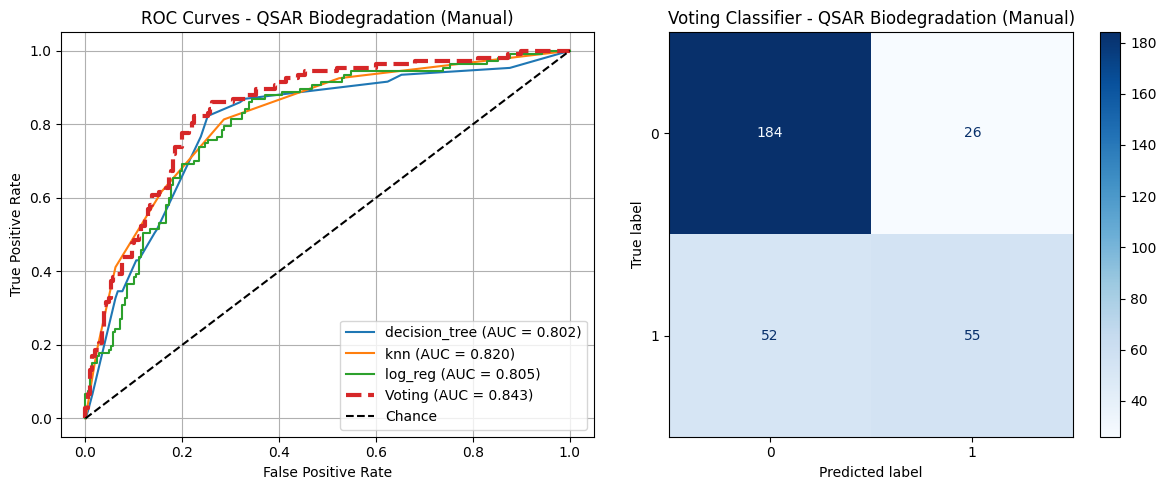


RUNNING BUILT-IN GRID SEARCH FOR QSAR BIODEGRADATION

--- GridSearchCV for decision_tree ---
Best params for decision_tree: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'selectkbest__k': 7}
Best CV score: 0.8033

--- GridSearchCV for knn ---
Best params for knn: {'classifier__n_neighbors': 5, 'classifier__p': 1, 'classifier__weights': 'uniform', 'selectkbest__k': 7}
Best CV score: 0.8362

--- GridSearchCV for log_reg ---
Best params for log_reg: {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs', 'selectkbest__k': 5}
Best CV score: 0.8225
Error processing QSAR Biodegradation: evaluate_models() takes from 4 to 5 positional arguments but 7 were given

PROCESSING COMPLETE FOR THE SELECTED DATASET!


In [17]:
# --- Run Pipeline for All Datasets ---
datasets = [
    (load_wine_quality, "Wine Quality"),
    (load_hr_attrition, "HR Attrition"),
    (load_banknote, "Banknote Authentication"),
    (load_qsar_biodegradation, "QSAR Biodegradation")
]

# Select a single dataset to run the pipeline on
dataset_loader, dataset_name = datasets[1]  # This selects the HR Attrition dataset

try:
    run_complete_pipeline(dataset_loader, dataset_name)
except Exception as e:
    print(f"Error processing {dataset_name}: {e}")

print("\n" + "="*80)
print("PROCESSING COMPLETE FOR THE SELECTED DATASET!")
print("="*80)
